# 🦷 Panoramic FDI Tooth-Numbering — **YOLO26x** (single RTX PRO 6000, 96 GB)

**Self-contained:** import → *Run All*. Pulls the `quadrant_enumeration` panoramic set from
Google Drive, fuses its two-level labels into single **FDI** codes, applies **CLAHE** contrast
preprocessing, makes a seeded train/valid/test split, trains **YOLO26x** (NMS-free end-to-end),
evaluates on the held-out test split, and saves the model + predictions + graphs. This is the
YOLO twin of the panoramic RF-DETR-2XL notebook — same data pipeline, different detector.

### Task ≠ generic detection — the one rule that matters
FDI is defined by **position in the mouth**, so:

> **No horizontal/vertical flip.** YOLO flips by default (`fliplr=0.5`); a left↔right flip
> swaps quadrant 1↔2 and 4↔3, a top↔bottom flip swaps upper↔lower — either keeps the old
> label on the moved tooth and poisons the position→number map. We train with
> **`fliplr=0.0, flipud=0.0`**.

The rest of the augmentation mirrors RF-DETR's `AUG_CONFIG`: a small (±7°) rotate + brightness,
with `translate=0.0, scale=0.0`. **Mosaic stays on** (`mosaic=1.0`, transforms boxes correctly
so labels remain valid) and is closed for the last epochs to refine — the one intentional
departure from RF-DETR, since mosaic usually helps dense panoramic detection.

### What makes this dataset different
* **Two label fields per tooth.** Each box carries `category_id_1` (quadrant 1–4) and
  `category_id_2` (position 1–8). FDI = `quadrant*10 + position` → **32 classes**
  (11–18, 21–28, 31–38, 41–48). We fuse them into one class.
* **No public test labels.** Only the labelled *train* json ships (634 images), so we carve
  our **own 80/10/10 split** (seeded) for honest held-out evaluation.
* **Grayscale radiographs, heavy exposure variation.** We bake **CLAHE (clip 2.0, 8×8)** into
  every image — applied identically to train **and** valid/test, so it is *preprocessing*, not
  a random augmentation. (Verified: clip 2.0 lifts root/crown detail; clip 3–4 amplifies bone
  noise.)

### Recipe (Ultralytics YOLO26 defaults)
`yolo26x.pt` · `imgsz=640` · `epochs=150` · `patience=30` · `optimizer=auto` (MuSGD for long
runs) · `fliplr=0.0`. YOLO26 is end-to-end (no NMS) — standard `train()`/`val()`.

## 1 · Environment
YOLO26 ships in recent **ultralytics**; we upgrade to be safe. The Vast.ai image already has
torch/CUDA. We add `gdown` for the Drive download. `yolo26x.pt` auto-downloads on first use.

In [1]:
!nvidia-smi

Tue Jun 30 15:49:35 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 595.58.03              Driver Version: 595.58.03      CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX PRO 6000 Blac...    On  |   00000000:01:00.0 Off |                  Off |
| 43%   32C    P8             20W /  600W |       2MiB /  97887MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import sys
!{sys.executable} -m pip install --upgrade pip
!{sys.executable} -m pip install -U ultralytics opencv-python-headless pandas matplotlib pyyaml gdown

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 17.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 18.9 MB/s  0:00:03 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 19.2 MB/s  0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 18.4 MB/s  0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 19.1 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 16.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 20.4 MB/s  0:00:03m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 837.6/837.6 kB 13.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 MB 22.4 MB/s  0:00:02 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21/21 [ultralytics] [ultralytics]p4]eadless]


In [3]:
import os, json, glob, random, shutil, gc, time, datetime, re, zipfile
from collections import Counter, defaultdict
from pathlib import Path

import numpy as np
import cv2
import pandas as pd
import matplotlib.pyplot as plt
import torch
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

import ultralytics
print("ultralytics", ultralytics.__version__,
      "| Torch:", torch.__version__, "| CUDA:", torch.cuda.is_available())
for i in range(torch.cuda.device_count()):
    print("  GPU", i, torch.cuda.get_device_name(i),
          f"{torch.cuda.get_device_properties(i).total_memory/1024**3:.0f} GB")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
ultralytics 8.4.83 | Torch: 2.12.0+cu130 | CUDA: True
  GPU 0 NVIDIA RTX PRO 6000 Blackwell Workstation Edition 95 GB


## 2 · Configuration — edit this one cell

In [4]:
# ---- source (Google Drive zip of the quadrant_enumeration set) --------------
GDRIVE_FILE_ID   = "196Ozq1z4idER_KfBFdQOASocMn4mjpCi"   # from the share link
ANN_JSON_GLOB    = "*quadrant_enumeration*.json"          # found inside the zip
XRAYS_DIRNAME    = "xrays"                                 # image folder inside the zip

# ---- split (no public test labels -> we make our own) -----------------------
SPLIT_FRACS = {"train": 0.80, "valid": 0.10, "test": 0.10}

# ---- preprocessing: CLAHE (deterministic, ALL splits) -----------------------
CLAHE_CLIP = 2.0
CLAHE_GRID = 8        # 8x8 tiles — verified best contrast/noise trade-off for these panos

# ---- FDI classes (32 permanent teeth) — fixed standard order ----------------
CLASSES = [str(q*10 + t) for q in range(1, 5) for t in range(1, 9)]   # 11..18,21..28,31..38,41..48
NUM_CLASSES = len(CLASSES)                  # 32
CLS_IDX = {n: i for i, n in enumerate(CLASSES)}        # YOLO: 0-based, '11'->0 ...

# ---- YOLO26x training (single RTX PRO 6000, 96 GB) --------------------------
YOLO_MODEL   = "yolo26x.pt"
IMGSZ        = 640                   # YOLO26x setting (same as the intraoral YOLO26x notebook)
EPOCHS       = 150
PATIENCE     = 30                    # early-stop after N epochs w/o val improvement.
                                     # > close_mosaic (15) so the mosaic-off refinement
                                     # epochs can land before patience can ever trip.
BATCH        = 64                    # OOM? lower to 32/16. (or set -1 for auto)
OPTIMIZER    = "auto"                # -> MuSGD for long runs (YOLO26 default)
# Augmentation = an EXACT translation of the RF-DETR panoramic AUG_CONFIG to YOLO params.
# RF-DETR does ONLY: RandomBrightnessContrast(0.15) + Rotate(7) + GaussNoise + GaussianBlur,
# with NO flips and NO other geometric transform (no mosaic/translate/scale). So we zero out
# every YOLO default geometric/photometric aug except the two RF-DETR equivalents YOLO can
# express: degrees=7 (Rotate limit=7) and hsv_v=0.15 (brightness_limit=0.15, value only —
# grayscale so no hue/sat). YOLO has NO hyperparameter for contrast_limit, GaussNoise, or
# GaussianBlur, and no per-aug probability, so those parts of RF-DETR cannot be matched here.
AUG = dict(
    fliplr=0.0, flipud=0.0,          # no flips (flips swap quadrants) — matches RF-DETR
    degrees=7.0,                     # RF-DETR Rotate limit=7 (small tilt, never swaps a quadrant)
    hsv_h=0.0, hsv_s=0.0, hsv_v=0.15,# RF-DETR RandomBrightnessContrast brightness_limit=0.15 (value only)
    # mosaic ON (transforms boxes correctly, so labels stay valid) and closed near the end so
    # the final epochs refine on un-mosaicked images. This is the one intentional departure from
    # RF-DETR (which has no mosaic) — it usually helps dense panoramic detection.
    mosaic=1.0, close_mosaic=15,
    # other geometric aug OFF: RF-DETR does none of it (no translate/scale/shear/etc.)
    translate=0.0, scale=0.0, shear=0.0, perspective=0.0,
    mixup=0.0, copy_paste=0.0, erasing=0.0,
)

WORK = os.path.abspath("panoramic_fdi_yolo_run")
os.makedirs(WORK, exist_ok=True)
print(f"Train {YOLO_MODEL} @ imgsz {IMGSZ}, batch {BATCH}, {EPOCHS} epochs, "
      f"patience {PATIENCE}, optimizer {OPTIMIZER}")
print(f"CLAHE clip={CLAHE_CLIP} grid={CLAHE_GRID}x{CLAHE_GRID}")
print("Augmentation (flips OFF):", AUG)
print("WORK =", WORK)

Train yolo26x.pt @ imgsz 640, batch 64, 150 epochs, patience 30, optimizer auto
CLAHE clip=2.0 grid=8x8
Augmentation (flips OFF): {'fliplr': 0.0, 'flipud': 0.0, 'degrees': 7.0, 'hsv_h': 0.0, 'hsv_s': 0.0, 'hsv_v': 0.15, 'mosaic': 1.0, 'close_mosaic': 15, 'translate': 0.0, 'scale': 0.0, 'shear': 0.0, 'perspective': 0.0, 'mixup': 0.0, 'copy_paste': 0.0, 'erasing': 0.0}
WORK = /panoramic_fdi_yolo_run


## 3 · Download + unzip from Google Drive
Downloads the zip, extracts it, and locates the annotation json and the `xrays/` folder
wherever they sit inside the archive.

In [5]:
import gdown
DL_DIR = os.path.join(WORK, "download"); os.makedirs(DL_DIR, exist_ok=True)
zip_path = os.path.join(DL_DIR, "quadrant_enumeration.zip")
if not os.path.exists(zip_path) or os.path.getsize(zip_path) < 1_000_000:
    gdown.download(id=GDRIVE_FILE_ID, output=zip_path, quiet=False)
print("zip:", zip_path, f"{os.path.getsize(zip_path)/1e6:.0f} MB")

RAW_DIR = os.path.join(DL_DIR, "extracted")
if not os.path.isdir(RAW_DIR):
    with zipfile.ZipFile(zip_path) as zf:
        zf.extractall(RAW_DIR)

# locate annotation json + image dir anywhere under RAW_DIR
ann_hits = glob.glob(os.path.join(RAW_DIR, "**", ANN_JSON_GLOB), recursive=True)
assert ann_hits, f"no {ANN_JSON_GLOB} found under {RAW_DIR}"
ANN_JSON = ann_hits[0]
xray_hits = [d for d in glob.glob(os.path.join(RAW_DIR, "**", XRAYS_DIRNAME), recursive=True)
             if os.path.isdir(d)]
assert xray_hits, f"no '{XRAYS_DIRNAME}' folder found under {RAW_DIR}"
XRAYS_DIR = xray_hits[0]
print("annotation json:", ANN_JSON)
print("xrays dir:", XRAYS_DIR, "| images:", len(os.listdir(XRAYS_DIR)))

Downloading...
From (original): https://drive.google.com/uc?id=196Ozq1z4idER_KfBFdQOASocMn4mjpCi
From (redirected): https://drive.google.com/uc?id=196Ozq1z4idER_KfBFdQOASocMn4mjpCi&confirm=t&uuid=0ae47d52-723a-4b3a-bd00-56c9d924e146
To: /panoramic_fdi_yolo_run/download/quadrant_enumeration.zip
100%|██████████| 1.72G/1.72G [00:46<00:00, 36.8MB/s]


zip: /panoramic_fdi_yolo_run/download/quadrant_enumeration.zip 1718 MB
annotation json: /panoramic_fdi_yolo_run/download/extracted/quadrant_enumeration/train_quadrant_enumeration.json
xrays dir: /panoramic_fdi_yolo_run/download/extracted/quadrant_enumeration/xrays | images: 634


## 4 · Fuse FDI labels · CLAHE · split · write a YOLO dataset
For every annotation we compute the FDI code from `(category_id_1, category_id_2)` and map it to
a contiguous YOLO class id `0..31`. We then shuffle the 634 images (seeded), split **80/10/10**,
CLAHE-process each image, and write **YOLO format**:
`CLEAN_DIR/{train,valid,test}/images/*` + `…/labels/*.txt` (normalized `cls cx cy w h`) plus
a `data.yaml`. Images keep their source codec (e.g. `.png`) so the CLAHE'd pixels stay
lossless — identical to what the RF-DETR notebook writes.

> CLAHE is applied to **every** split (train *and* valid/test) so the model sees the same
> contrast distribution at train and inference time — it is preprocessing, not augmentation.

In [6]:
CLEAN_DIR = os.path.join(WORK, "dataset_fdi_yolo")
if os.path.exists(CLEAN_DIR): shutil.rmtree(CLEAN_DIR)
for s in ["train", "valid", "test"]:
    os.makedirs(os.path.join(CLEAN_DIR, s, "images"), exist_ok=True)
    os.makedirs(os.path.join(CLEAN_DIR, s, "labels"), exist_ok=True)

raw = json.load(open(ANN_JSON))
images = raw["images"]; im_by_id = {im["id"]: im for im in images}

# fuse the two label fields into one FDI name; group boxes by image
anns_by_img = defaultdict(list); skipped = 0
for a in raw["annotations"]:
    q = a.get("category_id_1"); t = a.get("category_id_2")
    if q is None or t is None: skipped += 1; continue
    fdi = str((q + 1) * 10 + (t + 1))
    if fdi not in CLS_IDX: skipped += 1; continue
    anns_by_img[a["image_id"]].append((fdi, a["bbox"]))   # bbox = [x, y, w, h] pixels
print(f"fused {sum(len(v) for v in anns_by_img.values())} boxes into FDI codes; skipped {skipped}")

# seeded split over IMAGE ids
img_ids = [im["id"] for im in images]
rng = random.Random(SEED); rng.shuffle(img_ids)
n = len(img_ids); n_tr = int(n*SPLIT_FRACS["train"]); n_va = int(n*SPLIT_FRACS["valid"])
split_of = {}
for i, iid in enumerate(img_ids):
    split_of[iid] = "train" if i < n_tr else ("valid" if i < n_tr + n_va else "test")

clahe = cv2.createCLAHE(clipLimit=CLAHE_CLIP, tileGridSize=(CLAHE_GRID, CLAHE_GRID))
def clahe_bgr(src):
    g = cv2.imread(src, cv2.IMREAD_GRAYSCALE)
    if g is None: return None
    return cv2.cvtColor(clahe.apply(g), cv2.COLOR_GRAY2BGR)   # 3-ch for the backbone

def write_label(path, anns, W, H):
    lines = []
    for nm, (x, y, w, h) in anns:
        cx = (x + w/2)/W; cy = (y + h/2)/H; ww = w/W; hh = h/H
        cx, cy = min(max(cx,0),1), min(max(cy,0),1); ww, hh = min(ww,1), min(hh,1)
        lines.append(f"{CLS_IDX[nm]} {cx:.6f} {cy:.6f} {ww:.6f} {hh:.6f}")
    with open(path, "w") as f: f.write("\n".join(lines))

def find_src(fn):
    src = os.path.join(XRAYS_DIR, fn)
    if os.path.exists(src): return src
    cand = glob.glob(os.path.join(XRAYS_DIR, "**", fn), recursive=True)
    return cand[0] if cand else None

counts = {s: [0, 0] for s in ["train", "valid", "test"]}; nmiss = 0   # [images, boxes]
for iid in tqdm(img_ids, desc="CLAHE + write YOLO"):
    s = split_of[iid]; im = im_by_id[iid]
    W, H = im["width"], im["height"]; anns = anns_by_img.get(iid, [])
    src = find_src(os.path.basename(im["file_name"]))
    if src is None: nmiss += 1; continue
    img = clahe_bgr(src)
    if img is None: nmiss += 1; continue
    stem = str(iid)
    # keep the SOURCE extension/codec (RF-DETR writes the original filename) so the CLAHE'd
    # pixels stay lossless — writing .jpg here would JPEG-recompress and diverge from RF-DETR.
    ext = os.path.splitext(os.path.basename(im["file_name"]))[1].lower() or ".png"
    cv2.imwrite(os.path.join(CLEAN_DIR, s, "images", stem + ext), img)
    write_label(os.path.join(CLEAN_DIR, s, "labels", stem + ".txt"), anns, W, H)
    counts[s][0] += 1; counts[s][1] += len(anns)
print("missing images:", nmiss)

DATA_YAML = os.path.join(CLEAN_DIR, "data.yaml")
import yaml
with open(DATA_YAML, "w") as f:
    yaml.safe_dump({"path": CLEAN_DIR, "train": "train/images", "val": "valid/images",
                    "test": "test/images", "names": {i: n for i, n in enumerate(CLASSES)}},
                   f, sort_keys=False)
for s in ["train", "valid", "test"]:
    print(f"[{s:5}] images={counts[s][0]:4d} boxes={counts[s][1]:5d}")
print("YOLO dataset ->", CLEAN_DIR, "| data.yaml ->", DATA_YAML)

fused 18095 boxes into FDI codes; skipped 0


CLAHE + write YOLO:   0%|          | 0/634 [00:00<?, ?it/s]

missing images: 0
[train] images= 507 boxes=14494
[valid] images=  63 boxes= 1786
[test ] images=  64 boxes= 1815
YOLO dataset -> /panoramic_fdi_yolo_run/dataset_fdi_yolo | data.yaml -> /panoramic_fdi_yolo_run/dataset_fdi_yolo/data.yaml


## 5 · EDA — class balance, boxes/image, object size
Panoramic shots are **dense** (~28 teeth each); rarest are third molars (18/28/38/48). Read
straight from the YOLO label files.

In [7]:
def read_labels(split):
    cls = Counter(); per_img = []; areas = []
    for tp in glob.glob(os.path.join(CLEAN_DIR, split, "labels", "*.txt")):
        rows = [ln.split() for ln in open(tp) if ln.strip()]
        per_img.append(len(rows))
        for c, cx, cy, w, h in rows:
            cls[int(c)] += 1; areas.append(float(w)*float(h))   # normalized area
    return dict(n=len(glob.glob(os.path.join(CLEAN_DIR, split, "images", "*"))),
                cls=cls, bpi=per_img, areas=areas)

eda = {s: read_labels(s) for s in ["train", "valid", "test"]}
grand = sum(sum(eda[s]["cls"].values()) for s in eda)
print(f"{'FDI':<6}" + "".join(f"{s:>8}" for s in eda) + f"{'TOTAL':>8}{'%':>7}")
for i, nm in enumerate(CLASSES):
    tot = sum(eda[s]['cls'].get(i, 0) for s in eda)
    print(f"{nm:<6}" + "".join(f"{eda[s]['cls'].get(i,0):>8}" for s in eda)
          + f"{tot:>8}{100*tot/max(grand,1):>6.1f}%")
for s in eda:
    b = eda[s]['bpi']
    print(f"[{s}] images={eda[s]['n']} boxes/img={sum(b)/max(len(b),1):.2f} (max {max(b) if b else 0})")

areas = np.array(eda['train']['areas']); ap = areas * IMGSZ * IMGSZ
small = np.sum(ap < 32*32); medium = np.sum((ap>=32*32)&(ap<96*96)); large = np.sum(ap>=96*96)
t = max(len(areas), 1)
print(f"\nObject size @ {IMGSZ}px: small {100*small/t:.1f}% | medium {100*medium/t:.1f}% | large {100*large/t:.1f}%")

FDI      train   valid    test   TOTAL      %
11         503      62      63     628   3.5%
12         500      62      61     623   3.4%
13         495      61      62     618   3.4%
14         472      56      60     588   3.2%
15         450      58      57     565   3.1%
16         447      59      59     565   3.1%
17         463      56      59     578   3.2%
18         274      36      31     341   1.9%
21         502      63      62     627   3.5%
22         492      63      62     617   3.4%
23         497      62      62     621   3.4%
24         463      55      58     576   3.2%
25         445      58      57     560   3.1%
26         440      51      55     546   3.0%
27         462      58      56     576   3.2%
28         290      39      38     367   2.0%
31         503      61      63     627   3.5%
32         507      61      62     630   3.5%
33         504      63      63     630   3.5%
34         496      61      62     619   3.4%
35         474      56      58    

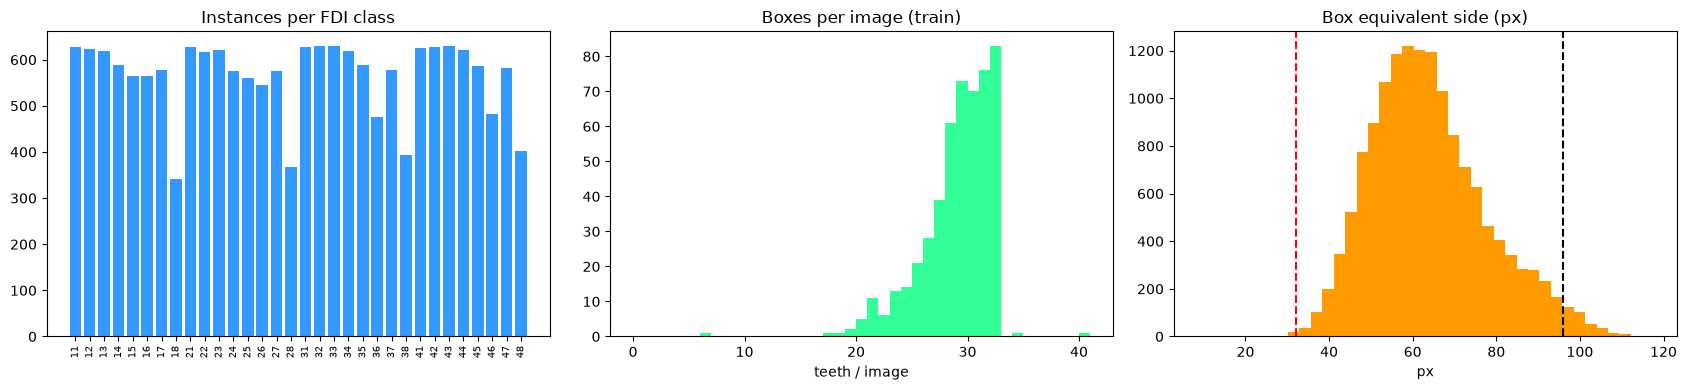

In [8]:
fig, ax = plt.subplots(1, 3, figsize=(17, 4))
counts = [sum(eda[s]['cls'].get(i, 0) for s in eda) for i in range(NUM_CLASSES)]
ax[0].bar(CLASSES, counts, color="#3399ff"); ax[0].set_title("Instances per FDI class")
ax[0].tick_params(axis='x', labelrotation=90, labelsize=7)
mx = max(eda['train']['bpi']) if eda['train']['bpi'] else 1
ax[1].hist(eda['train']['bpi'], bins=range(0, mx + 2), color="#33ff99")
ax[1].set_title("Boxes per image (train)"); ax[1].set_xlabel("teeth / image")
px_side = np.sqrt(np.array(eda['train']['areas'])) * IMGSZ
ax[2].hist(px_side, bins=40, color="#ff9b00")
ax[2].axvline(32, color="r", ls="--"); ax[2].axvline(96, color="k", ls="--")
ax[2].set_title("Box equivalent side (px)"); ax[2].set_xlabel("px")
plt.tight_layout(); plt.savefig(os.path.join(WORK, "eda_overview.png"), dpi=110); plt.show()

## 6 · Preprocessing & augmentation sanity-check
Top row proves the **CLAHE** preprocessing (raw grayscale → enhanced) with FDI boxes drawn.
Bottom row shows the **flip-free** augmentation we actually apply (brightness) next to the
disabled flip — rendered only to show *why it is off* (it would swap quadrants while keeping
labels). Mosaic (not shown) is safe because it transforms boxes along with the pixels;
translate/scale are disabled to stay close to RF-DETR.

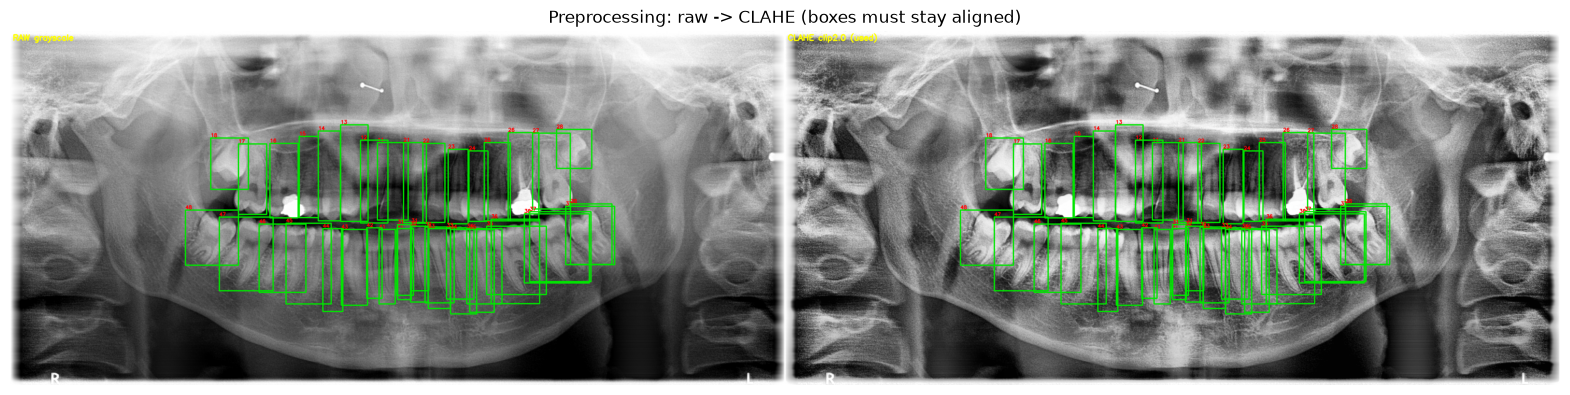

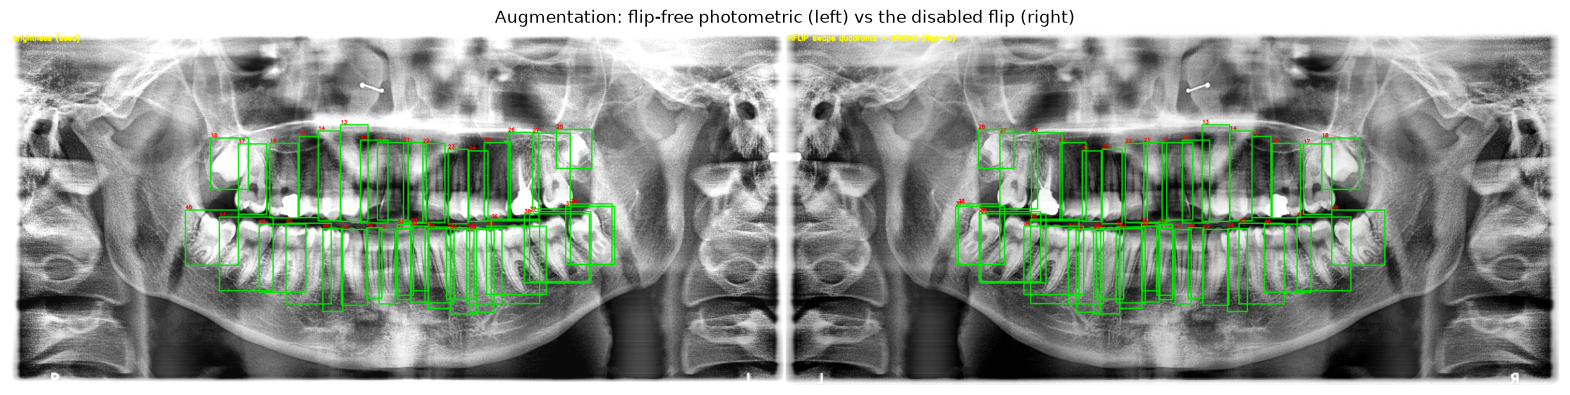

Confirmed: CLAHE keeps boxes aligned; training uses fliplr=0.0/flipud=0.0.


In [9]:
def draw_fdi(img, anns, flip=False):
    vis = img.copy(); W = vis.shape[1]
    if flip: vis = vis[:, ::-1].copy()
    for nm, (x, y, w, h) in anns:
        x, y, w, h = int(x), int(y), int(w), int(h)
        if flip: x = W - x - w
        cv2.rectangle(vis, (x, y), (x+w, y+h), (0, 230, 0), 3)
        cv2.putText(vis, nm, (x, max(y-4, 12)), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2)
    return vis

def bright(img): return cv2.convertScaleAbs(img, alpha=1.12, beta=8)

iid = max(anns_by_img, key=lambda i: len(anns_by_img[i]))
anns = anns_by_img[iid]
src = find_src(os.path.basename(im_by_id[iid]["file_name"]))
raw_gray = cv2.cvtColor(cv2.imread(src, cv2.IMREAD_GRAYSCALE), cv2.COLOR_GRAY2BGR)
clahe_img = clahe_bgr(src)

tiles_top = [cv2.cvtColor(draw_fdi(raw_gray, anns), cv2.COLOR_BGR2RGB),
             cv2.cvtColor(draw_fdi(clahe_img, anns), cv2.COLOR_BGR2RGB)]
for im, txt in zip(tiles_top, ["RAW grayscale", f"CLAHE clip{CLAHE_CLIP} (used)"]):
    cv2.putText(im, txt, (10, 34), cv2.FONT_HERSHEY_SIMPLEX, 1.0, (255, 255, 0), 3)
plt.figure(figsize=(20, 5)); plt.imshow(np.hstack(tiles_top)); plt.axis("off")
plt.title("Preprocessing: raw -> CLAHE (boxes must stay aligned)"); plt.show()

tiles_bot = [cv2.cvtColor(draw_fdi(bright(clahe_img), anns), cv2.COLOR_BGR2RGB),
             cv2.cvtColor(draw_fdi(clahe_img, anns, flip=True), cv2.COLOR_BGR2RGB)]
for im, txt in zip(tiles_bot, ["brightness (used)", "HFLIP swaps quadrants = WRONG (fliplr=0)"]):
    cv2.putText(im, txt, (10, 34), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 255, 0), 3)
plt.figure(figsize=(20, 5)); plt.imshow(np.hstack(tiles_bot)); plt.axis("off")
plt.title("Augmentation: flip-free photometric (left) vs the disabled flip (right)"); plt.show()
print("Confirmed: CLAHE keeps boxes aligned; training uses fliplr=0.0/flipud=0.0.")

## 7 · Train YOLO26x (flips disabled)
NMS-free end-to-end model, Ultralytics recipe. The augmentation mirrors RF-DETR's `AUG_CONFIG`
(no flips, no translate/scale; only `degrees=7` + `hsv_v=0.15`) plus mosaic on top.
`optimizer=auto` selects MuSGD for a long run; `patience=30` early-stops if val mAP plateaus
for 30 epochs (set above `close_mosaic=15` so the mosaic-off refinement always runs).
Outputs (weights, curves, confusion matrix) go under `WORK/yolo`.

An `on_fit_epoch_end` callback prints a **per-epoch metrics table** after every validation:
overall `mAP50-95 / mAP50 / mAP75 / F1 / Prec / Recall`, then per-class
`AP50-95 / F1 / Prec / Recall` (P/R/F1 at YOLO's best-F1 confidence).

> OOM? lower `BATCH` (64 → 32 → 16) or set `BATCH=-1` for auto.

In [10]:
from ultralytics import YOLO
YOLO_OUT = os.path.join(WORK, "yolo")
model = YOLO(YOLO_MODEL)

# ---- per-epoch metrics table (overall + per-class), printed after each val ----
# Ultralytics validates every epoch; this callback formats trainer.validator.metrics
# into the report layout: overall mAP50-95/50/75 + F1/Prec/Recall, then per-class
# AP50-95/F1/Prec/Recall. P/R/F1 are taken at YOLO's best-F1 confidence.
def make_epoch_printer():
    def _cb(trainer):
        box = getattr(getattr(getattr(trainer, "validator", None), "metrics", None), "box", None)
        if box is None: return
        ep = trainer.epoch + 1; tot = trainer.epochs
        mp, mr = float(box.mp), float(box.mr); f1 = 2*mp*mr/(mp+mr+1e-9)
        print(f"\n=== Val (Epoch {ep}/{tot}) — Overall ===")
        hdr = f"{'mAP50-95':>10}{'mAP50':>10}{'mAP75':>10}{'F1':>10}{'Prec':>10}{'Recall':>10}"
        print(hdr); print("-"*len(hdr))
        print(f"{box.map:>10.4f}{box.map50:>10.4f}{box.map75:>10.4f}{f1:>10.4f}{mp:>10.4f}{mr:>10.4f}")
        ph = f"{'Class':<8}{'AP50-95':>10}{'F1':>10}{'Prec':>10}{'Recall':>10}"
        print("--- Per-class ---"); print(ph); print("-"*len(ph))
        idx = list(box.ap_class_index)
        for c in range(NUM_CLASSES):
            if c in idx:
                k = idx.index(c); p, r, _ap50, ap = box.class_result(k)
                print(f"{CLASSES[c]:<8}{ap:>10.4f}{float(box.f1[k]):>10.4f}{p:>10.4f}{r:>10.4f}")
            else:
                print(f"{CLASSES[c]:<8}{'—':>10}{'—':>10}{'—':>10}{'—':>10}")
    return _cb

model.add_callback("on_fit_epoch_end", make_epoch_printer())

train_results = model.train(
    data=DATA_YAML, epochs=EPOCHS, patience=PATIENCE, imgsz=IMGSZ, batch=BATCH,
    optimizer=OPTIMIZER, seed=SEED, device=0, workers=8,
    project=YOLO_OUT, name="train", exist_ok=True, plots=True,
    **AUG,                                   # flips OFF + mild jitter
)
RUN_DIR = train_results.save_dir if hasattr(train_results, "save_dir") else os.path.join(YOLO_OUT, "train")
BEST = os.path.join(str(RUN_DIR), "weights", "best.pt")
print("Training done. best.pt ->", BEST)
!ls -la {os.path.join(str(RUN_DIR), 'weights')}

Ultralytics 8.4.83 🚀 Python-3.12.13 torch-2.12.0+cu130 CUDA:0 (NVIDIA RTX PRO 6000 Blackwell Workstation Edition, 97250MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=15, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/panoramic_fdi_yolo_run/dataset_fdi_yolo/data.yaml, degrees=7.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.0, exist_ok=True, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.0, hsv_s=0.0, hsv_v=0.15, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26x.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, o

### 7b · Resume training from `last.pt`
Run **either 7 or this** — never both in one kernel. YOLO restores model+optimizer+epoch from
`last.pt`; `epochs` in the original call is the TOTAL, so to train longer first bump `EPOCHS`
in §2 and re-run §7 fresh, or use this cell to finish an interrupted run.

In [ ]:
from ultralytics import YOLO
RUN_DIR = os.path.join(WORK, "yolo", "train")
last_pt = os.path.join(RUN_DIR, "weights", "last.pt")
assert os.path.exists(last_pt), f"missing {last_pt}"
model = YOLO(last_pt)

# same per-epoch metrics table as §7 (overall + per-class), printed after each val
def make_epoch_printer():
    def _cb(trainer):
        box = getattr(getattr(getattr(trainer, "validator", None), "metrics", None), "box", None)
        if box is None: return
        ep = trainer.epoch + 1; tot = trainer.epochs
        mp, mr = float(box.mp), float(box.mr); f1 = 2*mp*mr/(mp+mr+1e-9)
        print(f"\n=== Val (Epoch {ep}/{tot}) — Overall ===")
        hdr = f"{'mAP50-95':>10}{'mAP50':>10}{'mAP75':>10}{'F1':>10}{'Prec':>10}{'Recall':>10}"
        print(hdr); print("-"*len(hdr))
        print(f"{box.map:>10.4f}{box.map50:>10.4f}{box.map75:>10.4f}{f1:>10.4f}{mp:>10.4f}{mr:>10.4f}")
        ph = f"{'Class':<8}{'AP50-95':>10}{'F1':>10}{'Prec':>10}{'Recall':>10}"
        print("--- Per-class ---"); print(ph); print("-"*len(ph))
        idx = list(box.ap_class_index)
        for c in range(NUM_CLASSES):
            if c in idx:
                k = idx.index(c); p, r, _ap50, ap = box.class_result(k)
                print(f"{CLASSES[c]:<8}{ap:>10.4f}{float(box.f1[k]):>10.4f}{p:>10.4f}{r:>10.4f}")
            else:
                print(f"{CLASSES[c]:<8}{'—':>10}{'—':>10}{'—':>10}{'—':>10}")
    return _cb
model.add_callback("on_fit_epoch_end", make_epoch_printer())

train_results = model.train(resume=True)
BEST = os.path.join(RUN_DIR, "weights", "best.pt")
print("Resumed training done. best.pt ->", BEST)

## 8 · Evaluate on the TEST split (overall + per-class mAP)
Ultralytics `val(split='test')` gives mAP@50 / mAP@50-95 and per-class AP.

In [11]:
from ultralytics import YOLO
best = YOLO(BEST)
metrics = best.val(data=DATA_YAML, split="test", imgsz=IMGSZ, batch=BATCH,
                   project=os.path.join(WORK, "yolo"), name="val_test", exist_ok=True)
test_metrics = {"model": YOLO_MODEL, "weights": BEST, "imgsz": IMGSZ,
                "map50": float(metrics.box.map50), "map50_95": float(metrics.box.map)}
per_class = {}
try:
    maps = metrics.box.maps                       # per-class mAP50-95, indexed by class
    for i, nm in enumerate(CLASSES):
        if i < len(maps): per_class[nm] = {"AP50-95": float(maps[i])}
except Exception as e:
    print("[warn] per-class parse:", e)
test_metrics["per_class"] = per_class
json.dump(test_metrics, open(os.path.join(WORK, "test_metrics.json"), "w"), indent=2)
print(f"mAP50={test_metrics['map50']*100:.1f}  mAP50-95={test_metrics['map50_95']*100:.1f}")
print("per-class AP50-95:", json.dumps(per_class, indent=2))

Ultralytics 8.4.83 🚀 Python-3.12.13 torch-2.12.0+cu130 CUDA:0 (NVIDIA RTX PRO 6000 Blackwell Workstation Edition, 97250MiB)
YOLO26x summary (fused): 190 layers, 55,670,508 parameters, 0 gradients, 193.6 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 8010.8±275.6 MB/s, size: 4340.8 KB)
val: Scanning /panoramic_fdi_yolo_run/dataset_fdi_yolo/test/labels... 64 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 64/64 134.3it/s 0.5s.2s
val: New cache created: /panoramic_fdi_yolo_run/dataset_fdi_yolo/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 3.2s/it 3.2s
                   all         64       1815      0.905       0.91      0.928      0.518
                    11         63         63      0.874      0.877      0.922      0.537
                    12         61         61      0.891      0.902      0.934      0.502
                    13         62         62      0.928      0.836      0.893   

## 9 · Numbering metrics — *did we put the right FDI number on the tooth?*
Same numbering-specific measures as the RF-DETR notebook: a class-agnostic **detection** P/R
sweep, **exact-FDI** accuracy and **quadrant** accuracy on correctly-localized teeth, and a
top-confusions table. Predictions come from YOLO at conf 0.001 (keep nearly all), GT from the
YOLO test labels.

YOLO26x test infer:   0%|          | 0/64 [00:00<?, ?it/s]

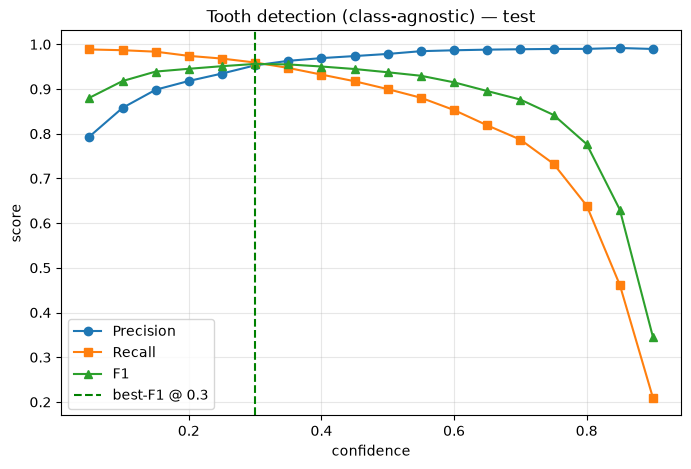

detect best-F1: P=95.3 R=95.9 F1=95.6 @conf=0.3
numbering (matched n=1741): exact FDI acc=95.2%  quadrant acc=99.6%
top confusions (gt -> pred):
   16 -> 17: 8
   15 -> 16: 6
   14 -> 15: 6
   27 -> 28: 6
   44 -> 45: 3
   17 -> 18: 3
   24 -> 25: 3
   46 -> 47: 3
   25 -> 26: 3
   26 -> 27: 3
   47 -> 48: 2
   13 -> 14: 2


In [12]:
def iou_matrix(a, b):
    if len(a) == 0 or len(b) == 0: return np.zeros((len(a), len(b)))
    a = np.asarray(a, float); b = np.asarray(b, float)
    ix1 = np.maximum(a[:,None,0], b[None,:,0]); iy1 = np.maximum(a[:,None,1], b[None,:,1])
    ix2 = np.minimum(a[:,None,2], b[None,:,2]); iy2 = np.minimum(a[:,None,3], b[None,:,3])
    iw = np.clip(ix2-ix1, 0, None); ih = np.clip(iy2-iy1, 0, None); inter = iw*ih
    aa = (a[:,2]-a[:,0])*(a[:,3]-a[:,1]); ab = (b[:,2]-b[:,0])*(b[:,3]-b[:,1])
    return inter / (aa[:,None] + ab[None,:] - inter + 1e-9)

# cache predictions + GT for every test image
test_imgs = sorted(glob.glob(os.path.join(CLEAN_DIR, "test", "images", "*")))
match_records = []
for ip in tqdm(test_imgs, desc="YOLO26x test infer"):
    H, W = cv2.imread(ip).shape[:2]
    res = best.predict(ip, imgsz=IMGSZ, conf=0.001, verbose=False)[0]
    pb = res.boxes.xyxy.cpu().numpy() if res.boxes is not None else np.zeros((0,4))
    pc = res.boxes.conf.cpu().numpy() if res.boxes is not None else np.zeros((0,))
    pl = res.boxes.cls.cpu().numpy().astype(int) if res.boxes is not None else np.zeros((0,),int)
    gt, gl = [], []
    lp = ip.replace(os.sep+"images"+os.sep, os.sep+"labels"+os.sep); lp = os.path.splitext(lp)[0]+".txt"
    for ln in open(lp):
        if not ln.strip(): continue
        c, cx, cy, w, h = ln.split(); cx, cy, w, h = float(cx)*W, float(cy)*H, float(w)*W, float(h)*H
        gt.append([cx-w/2, cy-h/2, cx+w/2, cy+h/2]); gl.append(int(c))
    match_records.append((np.asarray(pb,float).reshape(-1,4), np.asarray(pc,float).reshape(-1),
                          np.asarray(pl,int).reshape(-1), np.asarray(gt,float).reshape(-1,4),
                          np.asarray(gl,int).reshape(-1)))

def detect_sweep(conf, iou_thr=0.5):
    tp = fp = fn = 0
    for pb, pc, pl, gt, gl in match_records:
        keep = pc >= conf; pbb = pb[keep]; order = np.argsort(-pc[keep]); pbb = pbb[order]
        if len(gt) == 0: fp += len(pbb); continue
        if len(pbb) == 0: fn += len(gt); continue
        ious = iou_matrix(pbb, gt); matched = np.zeros(len(gt), bool)
        for i in range(len(pbb)):
            j = int(np.argmax(ious[i]))
            if ious[i, j] >= iou_thr and not matched[j]: matched[j] = True; tp += 1
            else: fp += 1
        fn += int(np.sum(~matched))
    prec = tp/(tp+fp+1e-9); rec = tp/(tp+fn+1e-9)
    return dict(conf=round(float(conf),3), tp=tp, fp=fp, fn=fn,
                precision=float(prec), recall=float(rec), f1=float(2*prec*rec/(prec+rec+1e-9)))

sweep = [detect_sweep(c) for c in np.round(np.arange(0.05, 0.91, 0.05), 2)]
best_f1 = max(sweep, key=lambda d: d["f1"])

def numbering_accuracy(conf, iou_thr=0.5):
    correct = quad_correct = total = 0; confusion = Counter()
    for pb, pc, pl, gt, gl in match_records:
        keep = pc >= conf; pbb = pb[keep]; pcc = pc[keep]; pll = pl[keep]
        order = np.argsort(-pcc); pbb = pbb[order]; pll = pll[order]
        if len(gt) == 0 or len(pbb) == 0: continue
        ious = iou_matrix(pbb, gt); matched = np.zeros(len(gt), bool)
        for i in range(len(pbb)):
            j = int(np.argmax(ious[i]))
            if ious[i, j] >= iou_thr and not matched[j]:
                matched[j] = True; total += 1
                gnm = CLASSES[int(gl[j])]; pnm = CLASSES[int(pll[i])]
                if pnm == gnm: correct += 1
                else: confusion[(gnm, pnm)] += 1
                if pnm[:1] == gnm[:1]: quad_correct += 1
    return dict(matched=total, exact_acc=correct/max(total,1),
                quadrant_acc=quad_correct/max(total,1), top_confusions=confusion.most_common(12))

num_at_bestf1 = numbering_accuracy(best_f1["conf"])
numbering = {"detect_sweep": sweep, "detect_best_f1": best_f1, "numbering_at_best_f1": num_at_bestf1}
json.dump(numbering, open(os.path.join(WORK, "numbering_metrics.json"), "w"), indent=2, default=str)

cs = [d["conf"] for d in sweep]
plt.figure(figsize=(8,5))
plt.plot(cs, [d["precision"] for d in sweep], "o-", label="Precision")
plt.plot(cs, [d["recall"] for d in sweep], "s-", label="Recall")
plt.plot(cs, [d["f1"] for d in sweep], "^-", label="F1")
plt.axvline(best_f1["conf"], color="g", ls="--", label=f"best-F1 @ {best_f1['conf']}")
plt.xlabel("confidence"); plt.ylabel("score"); plt.title("Tooth detection (class-agnostic) — test")
plt.legend(); plt.grid(alpha=0.3)
os.makedirs(os.path.join(WORK, "plots"), exist_ok=True)
plt.savefig(os.path.join(WORK, "plots", "detection_pr.png"), dpi=120, bbox_inches="tight"); plt.show()
print(f"detect best-F1: P={best_f1['precision']*100:.1f} R={best_f1['recall']*100:.1f} "
      f"F1={best_f1['f1']*100:.1f} @conf={best_f1['conf']}")
print(f"numbering (matched n={num_at_bestf1['matched']}): exact FDI acc={num_at_bestf1['exact_acc']*100:.1f}%  "
      f"quadrant acc={num_at_bestf1['quadrant_acc']*100:.1f}%")
print("top confusions (gt -> pred):")
for (g, p), nn in num_at_bestf1["top_confusions"]:
    print(f"   {g} -> {p}: {nn}")

## 10 · Save annotated test predictions
At the best-F1 detection confidence — annotated images plus a JSON of per-image detections.

In [13]:
PRED_CONF = numbering["detect_best_f1"]["conf"]
pred_dir = os.path.join(WORK, "predictions_test"); os.makedirs(pred_dir, exist_ok=True)
pred_dump = {}
for ip in tqdm(test_imgs, desc="save predictions"):
    res = best.predict(ip, imgsz=IMGSZ, conf=PRED_CONF, verbose=False)[0]
    annotated = res.plot()                      # BGR ndarray with boxes+labels
    name = os.path.basename(ip); cv2.imwrite(os.path.join(pred_dir, name), annotated)
    dets = []
    if res.boxes is not None:
        for b, c, s in zip(res.boxes.xyxy.cpu().numpy(), res.boxes.cls.cpu().numpy().astype(int),
                           res.boxes.conf.cpu().numpy()):
            dets.append({"fdi": CLASSES[int(c)], "conf": float(s), "xyxy": [float(v) for v in b]})
    pred_dump[name] = dets
json.dump(pred_dump, open(os.path.join(pred_dir, "_predictions.json"), "w"), indent=2)
print("Saved annotated test predictions ->", pred_dir, f"(conf={PRED_CONF})")

save predictions:   0%|          | 0/64 [00:00<?, ?it/s]

Saved annotated test predictions -> /panoramic_fdi_yolo_run/predictions_test (conf=0.3)


## 11 · Training graphs + qualitative check
Ultralytics writes `results.png` (loss/mAP curves), `confusion_matrix.png`, and PR curves into
the run dir.

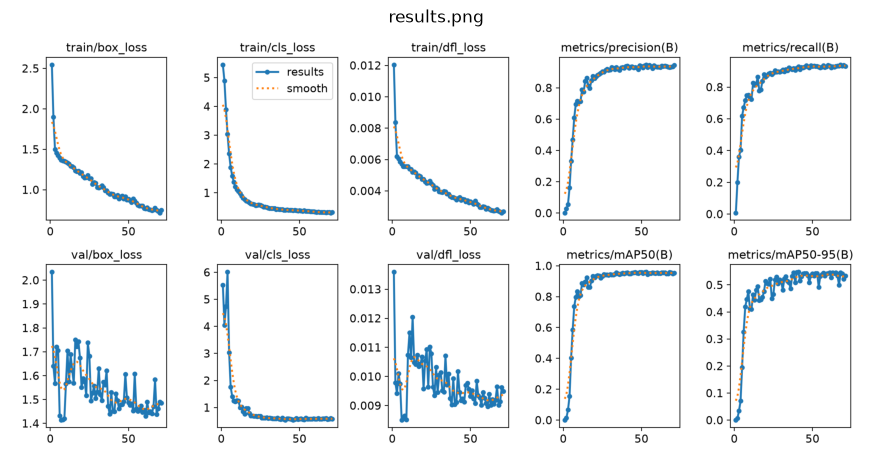

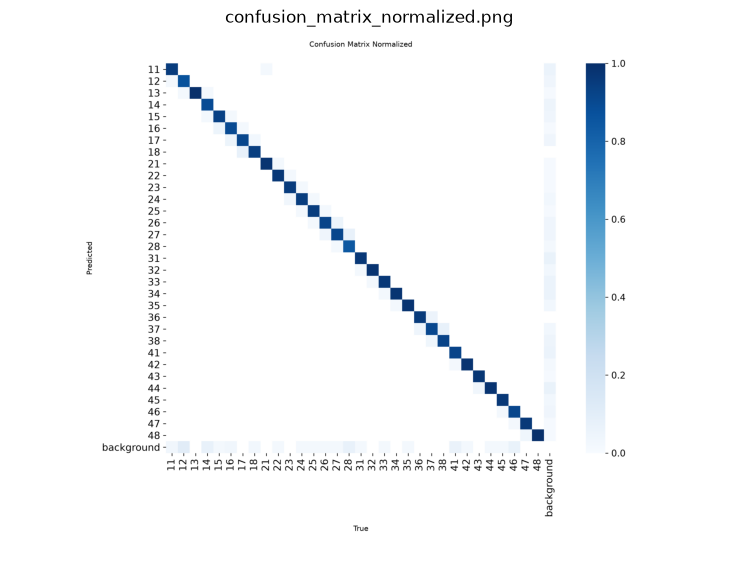

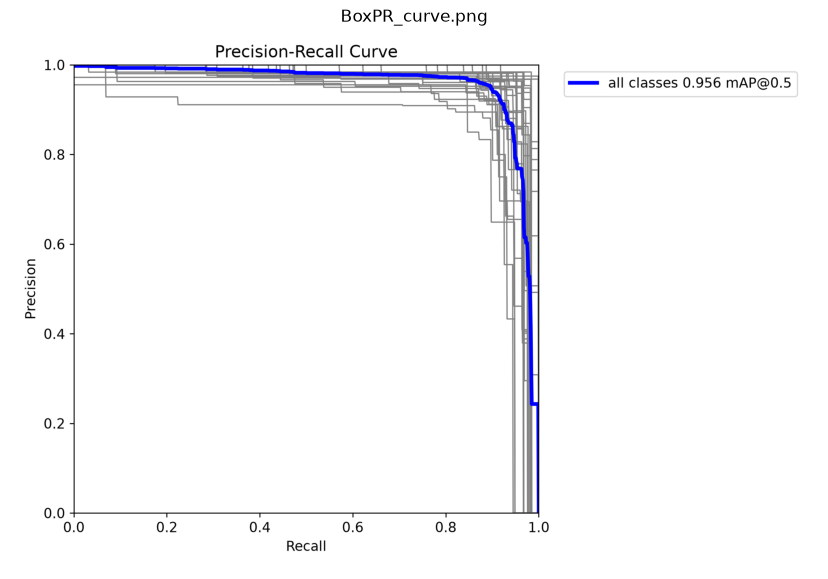

In [14]:
def load_yolo(stem_img):
    img = cv2.imread(stem_img); H, W = img.shape[:2]
    lp = stem_img.replace(os.sep+"images"+os.sep, os.sep+"labels"+os.sep)
    lp = os.path.splitext(lp)[0] + ".txt"
    boxes = []
    for ln in open(lp):
        if not ln.strip(): continue
        c, cx, cy, w, h = ln.split(); c = int(c)
        cx, cy, w, h = float(cx)*W, float(cy)*H, float(w)*W, float(h)*H
        boxes.append([c, cx-w/2, cy-h/2, cx+w/2, cy+h/2])
    return img, boxes

def draw_boxes(img, boxes):
    vis = img.copy()
    for c, x1, y1, x2, y2 in boxes:
        cv2.rectangle(vis, (int(x1), int(y1)), (int(x2), int(y2)), (0, 230, 0), 2)
        cv2.putText(vis, CLASSES[c], (int(x1), max(int(y1)-3, 10)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0, 0, 255), 1)
    return vis

for fnm in ["results.png", "confusion_matrix_normalized.png", "BoxPR_curve.png"]:
    p = os.path.join(str(RUN_DIR), fnm)
    if os.path.exists(p):
        plt.figure(figsize=(11, 7)); plt.imshow(plt.imread(p)); plt.axis("off")
        plt.title(fnm); plt.show()
    else:
        print("missing", p)

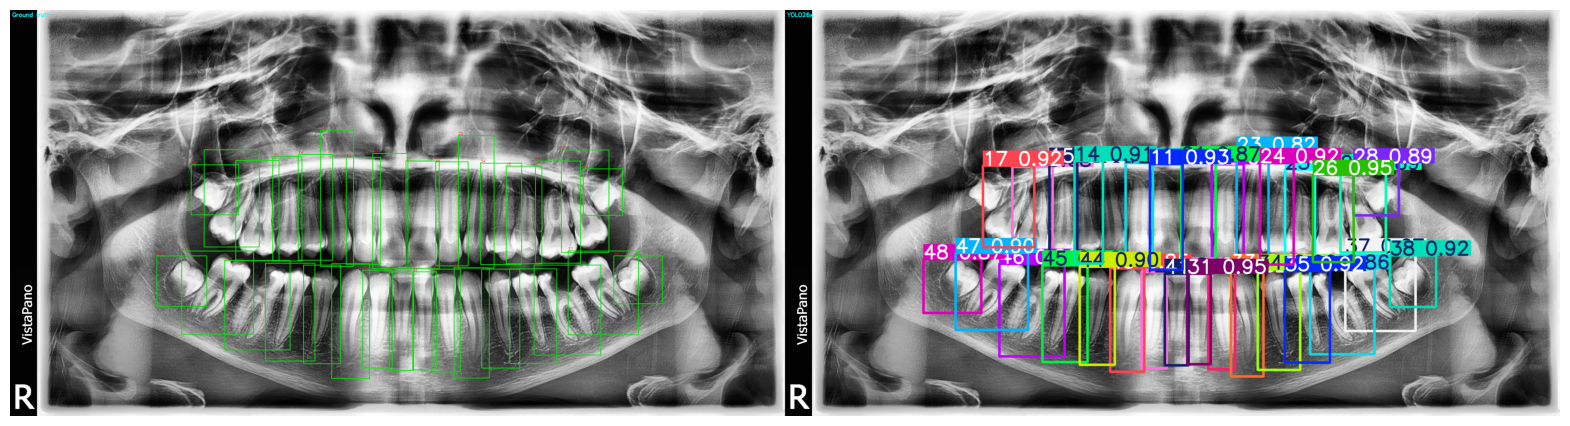

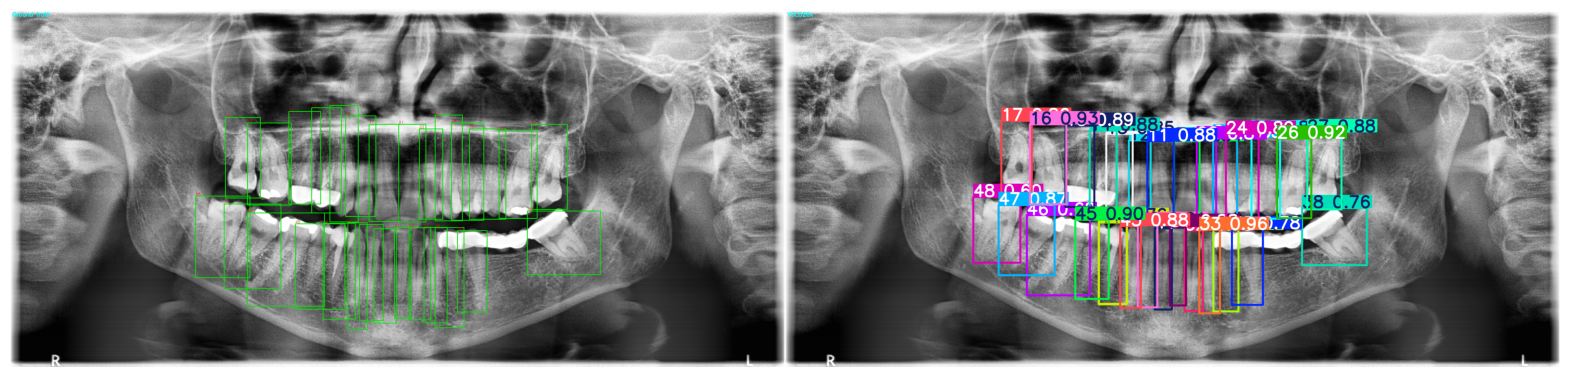

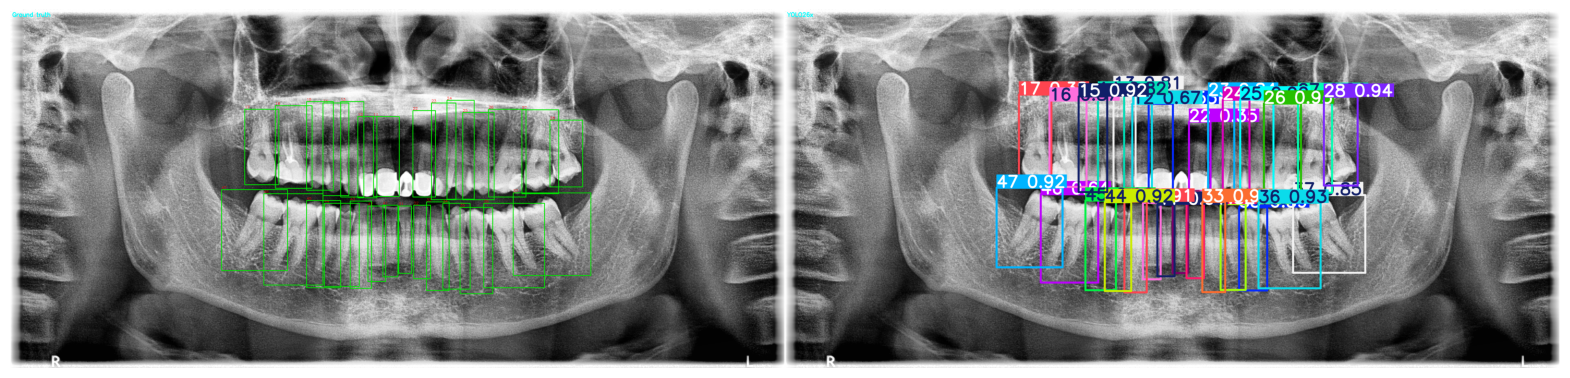

In [15]:
# GT vs prediction on a few test images
for ip in test_imgs[:3]:
    img, boxes = load_yolo(ip)
    gt = draw_boxes(img, boxes)
    res = best.predict(ip, imgsz=IMGSZ, conf=PRED_CONF, verbose=False)[0]
    pr = res.plot()
    cv2.putText(gt, "Ground truth", (8, 26), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255,255,0), 2)
    cv2.putText(pr, "YOLO26x", (8, 26), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255,255,0), 2)
    plt.figure(figsize=(20, 6))
    plt.imshow(np.hstack([cv2.cvtColor(gt, cv2.COLOR_BGR2RGB), cv2.cvtColor(pr, cv2.COLOR_BGR2RGB)]))
    plt.axis("off"); plt.show()

## 12 · Save the model + a results summary

In [16]:
shutil.copy2(BEST, os.path.join(WORK, "best.pt"))
summary = {"model": YOLO_MODEL, "task": "panoramic FDI tooth numbering (YOLO)",
           "imgsz": IMGSZ, "epochs": EPOCHS, "patience": PATIENCE, "batch": BATCH, "optimizer": OPTIMIZER,
           "classes": CLASSES, "clahe": {"clip": CLAHE_CLIP, "grid": CLAHE_GRID},
           "split_fracs": SPLIT_FRACS, "augmentation": AUG,
           "test_metrics": test_metrics,
           "numbering": {"detect_best_f1": numbering["detect_best_f1"],
                         "numbering_at_best_f1": numbering["numbering_at_best_f1"]},
           "artifacts": {"weights": os.path.join(WORK, "best.pt"),
                         "test_metrics": os.path.join(WORK, "test_metrics.json"),
                         "numbering_metrics": os.path.join(WORK, "numbering_metrics.json"),
                         "predictions": os.path.join(WORK, "predictions_test"),
                         "run_dir": str(RUN_DIR)}}
json.dump(summary, open(os.path.join(WORK, "summary.json"), "w"), indent=2, default=str)
print(json.dumps(summary["test_metrics"], indent=2))
print(json.dumps(summary["numbering"], indent=2, default=str))
print("\nAll artifacts under:", WORK)
for p in sorted(glob.glob(os.path.join(WORK, "*"))):
    print("  ", os.path.basename(p))

{
  "model": "yolo26x.pt",
  "weights": "/panoramic_fdi_yolo_run/yolo/train/weights/best.pt",
  "imgsz": 640,
  "map50": 0.9275979640592915,
  "map50_95": 0.5179922346528543,
  "per_class": {
    "11": {
      "AP50-95": 0.5371874576794791
    },
    "12": {
      "AP50-95": 0.5024141817577429
    },
    "13": {
      "AP50-95": 0.4249961503664621
    },
    "14": {
      "AP50-95": 0.4102093625455554
    },
    "15": {
      "AP50-95": 0.4624816575091672
    },
    "16": {
      "AP50-95": 0.5285982748597726
    },
    "17": {
      "AP50-95": 0.52090824505246
    },
    "18": {
      "AP50-95": 0.4608573621553885
    },
    "21": {
      "AP50-95": 0.5316357528215814
    },
    "22": {
      "AP50-95": 0.45778491680700784
    },
    "23": {
      "AP50-95": 0.47911772532694397
    },
    "24": {
      "AP50-95": 0.4326662475517079
    },
    "25": {
      "AP50-95": 0.44006443692567865
    },
    "26": {
      "AP50-95": 0.5629251344952122
    },
    "27": {
      "AP50-95": 0.577275

## 13 · Notes & levers
**Implemented**
1. **YOLO26x** (NMS-free end-to-end), fine-tuned from COCO-pretrained weights. ✅
2. **Flips disabled** (`fliplr=0.0, flipud=0.0`) — the core fix for positional FDI labels
   (flips swap quadrants / upper↔lower). ✅
3. **Two-field labels fused into single FDI codes** (`(q+1)*10 + (t+1)`, 32 classes). ✅
4. **CLAHE preprocessing** (clip 2.0, 8×8) baked into all splits — verified contrast lift. ✅
5. **Own seeded 80/10/10 split** (the public set has no test labels). ✅
6. **Per-epoch metrics table** (overall + per-class) + numbering-specific metrics
   (exact-FDI / quadrant accuracy + detection sweep). ✅

**Push higher if needed**
* Train longer (raise `EPOCHS`); keep `close_mosaic` so the last epochs refine without mosaic.
* Augmentation matches RF-DETR except **mosaic is ON** (an intentional YOLO advantage on dense
  detection). For a strict apples-to-apples comparison with RF-DETR, set `mosaic=0.0` in §2.
* If `18/28/38/48` lag, they are genuinely rarer (missing wisdom teeth) — consider
  class-balanced sampling or more data.
* Panoramic aspect ratios are wide (~2–3:1). YOLO letterboxes to a square `imgsz`; raising
  `IMGSZ` (880 → 1024) keeps small teeth resolvable if VRAM allows (lower `BATCH` to fit).
* `top_confusions` shows neighbour (14↔15) vs wrong-side (14↔24) errors.

**vs the panoramic RF-DETR-2XL notebook** — identical data/CLAHE/split/metrics, so the two are
directly comparable. YOLO26x is far faster to train/deploy and NMS-free; RF-DETR-2XL is heavier
and may edge ahead on dense small-object mAP. Run both, compare `test_metrics.json` + `numbering`.

**Caveats** — CLAHE is baked offline, so **any new image must get the same CLAHE before
inference** (clip 2.0, 8×8). The split is random by image; for a patient-disjoint split you would
group by patient id if one were available. YOLO26 weights are AGPL-3.0 (Ultralytics) — check
licensing for your use.